<a href="https://colab.research.google.com/github/healerHK/Data-Analyst---Workshop/blob/main/centrality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*italicized text*# Graph Data Analytics

In [5]:
!pip install networkx


In [14]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
G = nx.karate_club_graph()
#print(nx.info(G))
print("Graph data:", G.graph)
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
G = nx.karate_club_graph()
#print(nx.info(G))
print("Graph data:", G.graph)
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", f"{(2* G.number_of_edges() / G.number_of_nodes()):.4f}")
print("Graph type:", type(G))

Graph data: {'name': "Zachary's Karate Club"}
Graph data: {'name': "Zachary's Karate Club"}
Number of nodes: 34
Number of edges: 78
Average degree: 4.5882
Graph type: <class 'networkx.classes.graph.Graph'>


### Calculate page rank by using simple degree centrality

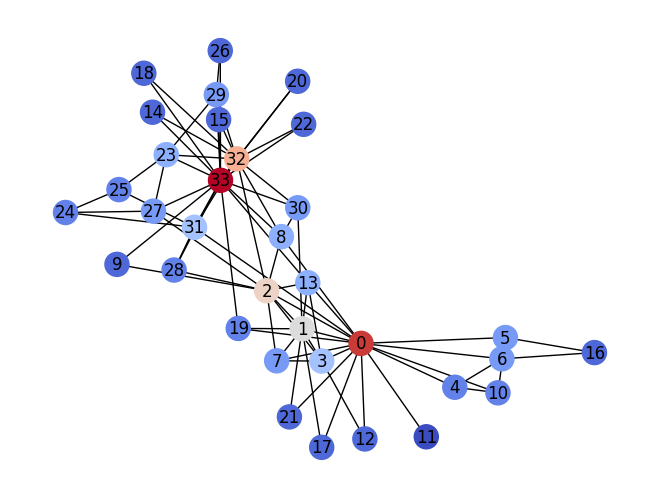

In [13]:
def simple_pagerank(G):
    p = np.array([G.degree(index) for node, index in enumerate(G.nodes())])
    return p

values = simple_pagerank(G)
nx.draw(G, cmap=plt.get_cmap('coolwarm'), node_color = values, with_labels=True)

### Calculate page rank by updating the centrality of each node with the iteration

(34,)


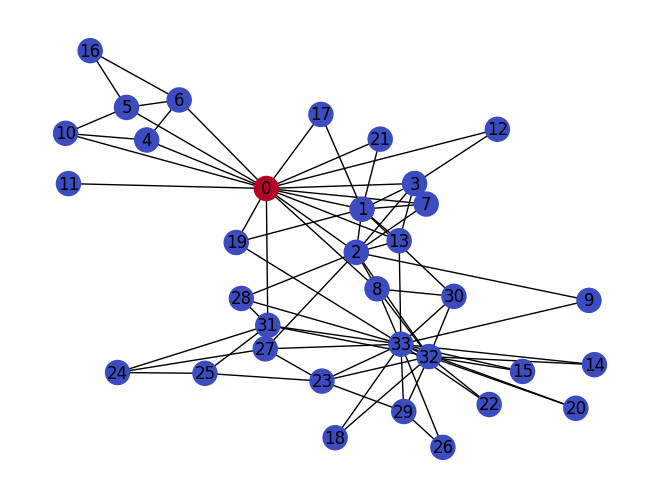

In [15]:
def pagerank_centrality(G, iter=100):
    p = np.array([1 for i in list(G.nodes())])
    print(p.shape)
    for k in range(iter):
        for i in G.nodes():
            for j in G.nodes():
                # update the centrality
                try:
                    p[i] += int(G.number_of_edges(i, j) * p[j] / G.degree[j])
                except:
                    pass

        norm = sum(p)
        p = p / norm
    return p


values = pagerank_centrality(G)
nx.draw(G, cmap=plt.get_cmap('coolwarm'), node_color = values, with_labels=True)

In [18]:
G = nx.read_edgelist("/content/gr0.California.edges.txt")
G.remove_nodes_from(list(nx.isolates(G)))
# The nx.info() function has been removed.

print("Graph data:", G.graph)
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", f"{(2* G.number_of_edges() / G.number_of_nodes()):.4f}")
print("Graph type:", type(G))

G1 = G.subgraph(list(G.nodes())[100:150])
print("Graph data:", G1.graph)
print("Number of nodes:", G1.number_of_nodes())
print("Number of edges:", G1.number_of_edges())
print("Average degree:", f"{(2* G1.number_of_edges() / G1.number_of_nodes()):.4f}")
print("Graph type:", type(G1))

Graph data: {}
Number of nodes: 6175
Number of edges: 15969
Average degree: 5.1721
Graph type: <class 'networkx.classes.graph.Graph'>
Graph data: {}
Number of nodes: 50
Number of edges: 42
Average degree: 1.6800
Graph type: <class 'networkx.classes.graph.Graph'>


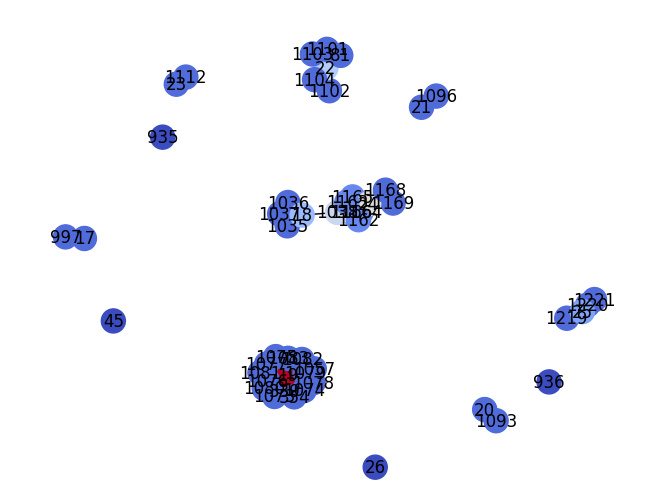

In [21]:
values = simple_pagerank(G1)
nx.draw(G1, cmap=plt.get_cmap('coolwarm'), node_color = values, with_labels=True)

(50,)


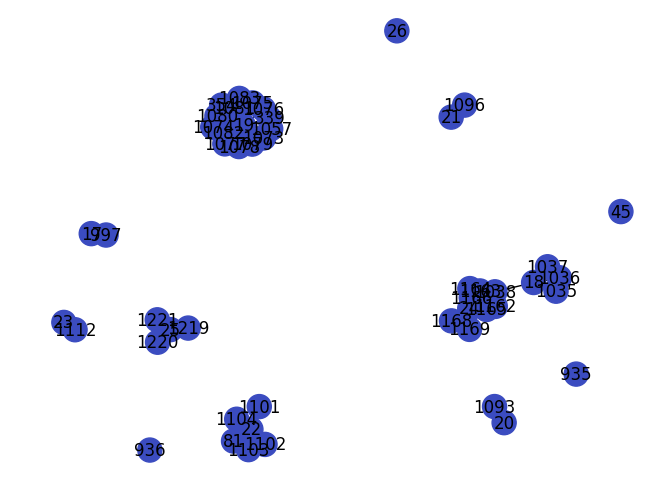

In [22]:
values = pagerank_centrality(G1)
nx.draw(G1, cmap=plt.get_cmap('coolwarm'), node_color = values, with_labels=True)